In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, log_loss, average_precision_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.calibration import CalibrationDisplay
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib
try:
    import optuna
except:
    ! pip install optuna
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

## Helper Classes and Functions

In [2]:
class GenericCleaning:
    def __init__(self):
        pass
    def fit(self, X):
        print('Generic cleaning...')
        return self
    def transform(self, X):
        print('Generic cleaning...')
        X = X.copy()
        # replace terms w val 0
        X['term_months'] = X['term_months'].replace(0, np.nan)
        # clean channel
        X['channel'] = X['channel'].str.lower().str.strip()
        return X

In [3]:
class FillMissing:
    def __init__(self, dict_fillna):
        self.dict_fillna = dict_fillna
    def fit(self, X):
        print('Calculating imputation value...')
        dict_impute = {}
        for key, val in tqdm(self.dict_fillna.items()):
            if val == 'max':
                val_impute = X[key].max()
            elif val == 'min':
                val_impute = X[key].min()
            elif val == 'missing':
                val_impute = 'missing'
            # assign
            dict_impute[key] = val_impute
        # save to object
        self.dict_impute = dict_impute
        return self
    def transform(self, X):
        print('Filling missing values...')
        X = X.copy()
        dict_impute = self.dict_impute
        list_cols = list(X.columns)
        dict_impute = {key: val for key, val in dict_impute.items() if key in list_cols}
        # impute
        for key, val in tqdm(dict_impute.items()):
            X[key] = X[key].fillna(val)
        return X

In [4]:
class FeatureEngineering:
    def __init__(self):
        pass
    def fit(self, X):
        print('Feature engineering...')
        # get unique channels
        list_channels_unique = list(X['channel'].unique())
        # save to object
        self.list_channels_unique = list_channels_unique
        return self
    def transform(self, X):
        print('Feature engineering...')
        X = X.copy()
        # log income
        X['ENG-stated_income_log'] = np.log1p(X['stated_income'])
        # loan to income
        X['ENG-loan_to_income'] = X['loan_amount'] / (X['stated_income'] + 1)
        # dummy channel (rm first item from list)
        for channel_unique in self.list_channels_unique[1:]:
            X[f'ENG-channel_{channel_unique}'] = (X['channel'] == channel_unique).astype(int)
        return X

In [5]:
class Winsorize:
    def __init__(self, list_cols_winsorize):
        self.list_cols_winsorize = list_cols_winsorize
    def fit(self, X):
        print('Calculating winsorization thresholds...')
        dict_bounds = {}
        for col in self.list_cols_winsorize:
            flt_lower = X[col].quantile(0.01)
            flt_upper = X[col].quantile(0.99)
            dict_bounds[col] = {'lower': flt_lower, 'upper': flt_upper}
        # save
        self.dict_bounds = dict_bounds
        return self
    def transform(self, X):
        print('Winsorizing features...')
        X = X.copy()
        dict_bounds = self.dict_bounds
        list_cols = list(X.columns)
        dict_bounds = {key: val for key, val in dict_bounds.items() if key in list_cols}
        for key, val in dict_bounds.items():
            X[key] = X[key].clip(val['lower'], val['upper'])
        return X

In [6]:
class ScaleFeatures:
    def __init__(self, list_cols_scale):
        self.list_cols_scale = list_cols_scale
    def fit(self, X):
        print('Calculating mean and standard deviations...')
        dict_scale = {}
        for col in self.list_cols_scale:
            flt_mn = X[col].mean()
            flt_sd = X[col].std(ddof=0)
            if flt_sd == 0:
                flt_sd = 1.0
            dict_scale[col] = {'mn': flt_mn, 'sd': flt_sd}
        self.dict_scale = dict_scale
        return self
    def transform(self, X):
        print('Scaling features...')
        X = X.copy()
        dict_scale = self.dict_scale
        list_cols = list(X.columns)
        dict_scale = {key: val for key, val in dict_scale.items() if key in list_cols}
        # scale
        for key, val in dict_scale.items():
            X[key] = (X[key] - val['mn']) / val['sd']
        return X

In [7]:
class PreprocessingModel:
    def __init__(self, list_cls_transformers):
        self.list_cls_transformers = list_cls_transformers
    def transform(self, X):
        for cls_transformer in self.list_cls_transformers:
            X = cls_transformer.transform(X)
        return X

In [8]:
def tune_lr_optuna(X_train, y_train, X_valid, y_valid, X_test, y_test, n_trials=10):
    """Bayesian hyperparameter optimization for Logistic Regression using Optuna."""
    best_model = [None]
    
    def objective(trial):
        C = trial.suggest_float('C', 1e-4, 100.0, log=True)
        class_weight = trial.suggest_categorical('class_weight', ['balanced', 'none'])
        cw = 'balanced' if class_weight == 'balanced' else None
        
        model = LogisticRegression(
            C=C,
            class_weight=cw,
            fit_intercept=True,
            max_iter=1000,
            random_state=42,
        )
        model.fit(X_train, y_train)
        
        y_hat_valid = model.predict_proba(X_valid)[:, 1]
        score = average_precision_score(y_valid, y_hat_valid)
        
        if best_model[0] is None or score > best_model[0][1]:
            best_model[0] = (model, score)
        
        return score
    
    pbar = tqdm(total=n_trials, desc=f'Optuna ({X_train.shape[1]} features)')
    def callback(study, trial):
        pbar.update(1)
        pbar.set_postfix({'best_pr_auc': f'{study.best_value:.4f}'})
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, callbacks=[callback])
    pbar.close()
    
    cls_model = best_model[0][0]
    y_hat_train = cls_model.predict_proba(X_train)[:, 1]
    y_hat_valid = cls_model.predict_proba(X_valid)[:, 1]
    y_hat_test = cls_model.predict_proba(X_test)[:, 1]
    
    dict_result = {
        'int_n_features': X_train.shape[1],
        'list_features': list(X_train.columns),
        'flt_roc_auc_train': roc_auc_score(y_train, y_hat_train),
        'flt_roc_auc_valid': roc_auc_score(y_valid, y_hat_valid),
        'flt_roc_auc_test': roc_auc_score(y_test, y_hat_test),
        'flt_pr_auc_train': average_precision_score(y_train, y_hat_train),
        'flt_pr_auc_valid': average_precision_score(y_valid, y_hat_valid),
        'flt_pr_auc_test': average_precision_score(y_test, y_hat_test),
        'best_params': study.best_params,
        'cls_model_inference': cls_model,
    }
    return dict_result

## Constants

In [9]:
str_bucket = 'credit-risk-model-demo'
print(f'Bucket: {str_bucket}')

str_task = '04_logistic_regression'
print(f'Task: {str_task}')

str_dirname_output = './output'

str_target = 'default_12m'

# data uri - import
str_filename = 'df.csv'
str_uri = f's3://{str_bucket}/02_split_data/{str_filename}'

# id cols
list_cols_no = [
    'loan_id',
    'origination_date',
    'dob', # dont want to FE age for compliance reasons
    #str_target,
    'charged_off_amount',
    'paid_interest_amount',
    'apr', # dont have until loan is scored
    'state', # can be sparse in states and cause overfitting + very hard to defend
    # 'data_set',
]

Bucket: credit-risk-model-demo
Task: 04_logistic_regression


## Output Directory

In [10]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Import Data

In [11]:
df = pd.read_csv(str_uri)

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


## Drop Post-Origination and Non-Predictive Columns

In [12]:
df.drop(list_cols_no, axis=1, inplace=True)
df

,loan_amount,term_months,channel,employment_length_years,stated_income,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,data_set
0,5410,18,partner,8.39,2951.0,0,604.0,1.0,1.0,0.47,3.0,1,0,train
1,10000,12,web,4.52,5410.0,0,600.0,2.0,0.0,0.46,3.0,0,0,train
2,8480,12,web,3.81,3244.0,0,557.0,2.0,0.0,0.48,5.0,2,0,train
3,3510,18,web,9.82,5147.0,1,651.0,3.0,0.0,0.18,1.0,0,0,train
4,6630,24,web,4.99,6389.0,1,611.0,1.0,0.0,0.41,3.0,1,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,6970,12,mobile,9.41,6511.0,0,607.0,2.0,1.0,0.47,4.0,1,0,test
25304,8450,12,mobile,8.97,4278.0,1,662.0,6.0,0.0,0.52,2.0,0,0,test
25305,970,24,web,4.01,3885.0,0,595.0,2.0,0.0,0.34,0.0,0,0,test
25306,5700,12,mobile,7.10,13121.0,0,583.0,2.0,0.0,0.31,2.0,2,0,test


## Extract Training Data (Fit Preprocessing on Training Only)

In [13]:
df_train = df[df['data_set'] == 'train'].copy()
df_train.drop('data_set', axis=1, inplace=True)
# X, y
list_cols = [col for col in df_train.columns if col != str_target]
X_train = df_train[list_cols].copy()
y_train = df_train[str_target]

## Build Preprocessing Pipeline (Fit on Training Data)

### Generic Cleaning

In [14]:
cls_cleaning = GenericCleaning()
cls_cleaning.fit(X_train)
X_train = cls_cleaning.transform(X_train)

Generic cleaning...
Generic cleaning...


### Pessimistic Imputation

In [15]:
dict_fillna = {
    'loan_amount': 'max',
    'term_months': 'min',
    'channel': 'missing',
    'employment_length_years': 'min',
    'stated_income': 'min',
    'has_prior_loans_with_us': 'min',
    'bureau_score': 'min',
    'open_trades': 'min',
    'delinq_12m': 'max',
    'utilization': 'max',
    'inquiries_6m': 'max',
    'public_records': 'max',
}
cls_impute = FillMissing(dict_fillna)
# fit
cls_impute.fit(X_train)
# transform
X_train = cls_impute.transform(X_train)

Calculating imputation value...


100%|██████████| 12/12 [00:00<00:00, 5256.57it/s]


Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 1743.93it/s]


### Feature Engineering

In [16]:
cls_fe = FeatureEngineering()
# fit
cls_fe.fit(X_train)
# transform
X_train = cls_fe.transform(X_train)

Feature engineering...
Feature engineering...


### Winsorization

In [17]:
list_cols_winsorize = [
    'employment_length_years',
    'bureau_score',
    'open_trades',
    'delinq_12m',
    'utilization',
    'inquiries_6m',
    'ENG-stated_income_log',
    'ENG-loan_to_income',
]
cls_winsorize = Winsorize(list_cols_winsorize=list_cols_winsorize)
# fit
cls_winsorize.fit(X_train)
# transform
X_train = cls_winsorize.transform(X_train)

Calculating winsorization thresholds...
Winsorizing features...


### Standardization (Z-Score Scaling)

In [18]:
list_cols_scale = [
    # 'loan_amount',
    'term_months',
    'employment_length_years',
    # 'stated_income',
    'bureau_score',
    'open_trades',
    'delinq_12m',
    'utilization',
    'inquiries_6m',
    'public_records',
    'ENG-stated_income_log',
    'ENG-loan_to_income',
]
cls_scaler = ScaleFeatures(
    list_cols_scale=list_cols_scale,
)
cls_scaler.fit(X_train)
X_train = cls_scaler.transform(X_train)

Calculating mean and standard deviations...
Scaling features...


### Assemble Preprocessing Pipeline

In [19]:
# list of transformers
list_cls_transformers = [
    cls_cleaning,
    cls_impute,
    cls_fe,
    cls_scaler,
    #cls_winsorize,
]
cls_model_preprocessing = PreprocessingModel(
    list_cls_transformers=list_cls_transformers,
)

### Save Preprocessing Pipeline

In [20]:
# save
str_filename = 'cls_model_preprocessing.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
joblib.dump(cls_model_preprocessing, str_local_path)

['./output/cls_model_preprocessing.joblib']

### Load Pipeline (Simulate Production)

In [21]:
cls_model_preprocessing = joblib.load(str_local_path)

## Transform Full Dataset (Pipeline Was Fit on Training Only)

In [22]:
df = cls_model_preprocessing.transform(
    X=df,
)
# show
df

Generic cleaning...
Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 1221.67it/s]


Feature engineering...
Scaling features...


,loan_amount,term_months,channel,employment_length_years,stated_income,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,data_set,ENG-stated_income_log,ENG-loan_to_income,ENG-channel_web,ENG-channel_missing,ENG-channel_mobile
0,5410,-0.112502,partner,0.399143,2951.0,0,-0.228496,-0.690017,0.799470,0.351978,0.565882,1.320739,0,train,-0.545096,-0.034441,0,0,0
1,10000,-0.735249,web,-0.167893,5410.0,0,-0.278789,-0.100690,-0.544859,0.309934,0.565882,-0.528412,0,train,0.210006,-0.031234,1,0,0
2,8480,-0.735249,web,-0.271923,3244.0,0,-0.819433,-0.100690,-0.544859,0.394022,1.677443,3.169889,0,train,-0.427171,0.127782,1,0,0
3,3510,-0.112502,web,0.608668,5147.0,1,0.362441,0.488638,-0.544859,-0.867309,-0.545678,-0.528412,0,train,0.147916,-0.273607,1,0,0
4,6630,0.510245,web,-0.099028,6389.0,1,-0.140484,-0.690017,-0.544859,0.099712,0.565882,1.320739,0,train,0.417240,-0.199678,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,6970,-0.735249,mobile,0.548595,6511.0,0,-0.190777,-0.100690,0.799470,0.351978,1.121662,1.320739,0,test,0.440808,-0.192867,0,0,1
25304,8450,-0.735249,mobile,0.484125,4278.0,1,0.500746,2.256621,-0.544859,0.562200,0.010102,-0.528412,0,test,-0.082482,-0.004909,0,0,1
25305,970,0.510245,web,-0.242619,3885.0,0,-0.341654,-0.100690,-0.544859,-0.194599,-1.101459,-0.528412,0,test,-0.202534,-0.363428,1,0,0
25306,5700,-0.735249,mobile,0.210131,13121.0,0,-0.492532,-0.100690,-0.544859,-0.320732,0.010102,3.169889,0,test,1.313911,-0.325029,0,0,1


## Feature Selection

In [23]:
list_cols_start = [
    #'loan_amount', # dont use because we have loan to income
    'term_months',
    'employment_length_years',
    'has_prior_loans_with_us',
    'bureau_score',
    'open_trades',
    'delinq_12m',
    'utilization',
    'inquiries_6m',
    'public_records',
    'ENG-stated_income_log',
    'ENG-loan_to_income',
    'ENG-channel_missing',
    'ENG-channel_mobile',
    'ENG-channel_web',
    str_target,
    'data_set',
]
df = df[list_cols_start].copy()
df

,term_months,employment_length_years,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,ENG-stated_income_log,ENG-loan_to_income,ENG-channel_missing,ENG-channel_mobile,ENG-channel_web,default_12m,data_set
0,-0.112502,0.399143,0,-0.228496,-0.690017,0.799470,0.351978,0.565882,1.320739,-0.545096,-0.034441,0,0,0,0,train
1,-0.735249,-0.167893,0,-0.278789,-0.100690,-0.544859,0.309934,0.565882,-0.528412,0.210006,-0.031234,0,0,1,0,train
2,-0.735249,-0.271923,0,-0.819433,-0.100690,-0.544859,0.394022,1.677443,3.169889,-0.427171,0.127782,0,0,1,0,train
3,-0.112502,0.608668,1,0.362441,0.488638,-0.544859,-0.867309,-0.545678,-0.528412,0.147916,-0.273607,0,0,1,0,train
4,0.510245,-0.099028,1,-0.140484,-0.690017,-0.544859,0.099712,0.565882,1.320739,0.417240,-0.199678,0,0,1,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,-0.735249,0.548595,0,-0.190777,-0.100690,0.799470,0.351978,1.121662,1.320739,0.440808,-0.192867,0,1,0,0,test
25304,-0.735249,0.484125,1,0.500746,2.256621,-0.544859,0.562200,0.010102,-0.528412,-0.082482,-0.004909,0,1,0,0,test
25305,0.510245,-0.242619,0,-0.341654,-0.100690,-0.544859,-0.194599,-1.101459,-0.528412,-0.202534,-0.363428,0,0,1,0,test
25306,-0.735249,0.210131,0,-0.492532,-0.100690,-0.544859,-0.320732,0.010102,3.169889,1.313911,-0.325029,0,1,0,0,test


## Train / Validation / Test Split

In [24]:
df_train = df[df['data_set'] == 'train'].copy()
df_valid = df[df['data_set'] == 'valid'].copy()
df_test = df[df['data_set'] == 'test'].copy()

## X, y Split

In [25]:
list_cols = [col for col in list_cols_start if col not in [str_target, 'data_set']]

# train
X_train = df_train[list_cols].copy()
y_train = df_train[str_target]

# valid
X_valid = df_valid[list_cols].copy()
y_valid = df_valid[str_target]

# test
X_test = df_test[list_cols].copy()
y_test = df_test[str_target]

## Multicollinearity Check (Variance Inflation Factor)

In [26]:
X_vif = X_train[list_cols_scale].copy()

# add constant
X_vif["intercept"] = 1

# make df
vif_data = pd.DataFrame()
# assign cols
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]
# sort
vif_data = vif_data.sort_values("VIF", ascending=False)
# show
vif_data

,feature,VIF
8,ENG-stated_income_log,1.794339
9,ENG-loan_to_income,1.793618
2,bureau_score,1.289137
3,open_trades,1.165011
7,public_records,1.113703
6,inquiries_6m,1.108947
5,utilization,1.037034
4,delinq_12m,1.022200
10,intercept,1.002606
1,employment_length_years,1.000847


## Bayesian Optimization with Dynamic Feature Elimination

For each iteration:
1. Tune hyperparameters with Optuna (Bayesian optimization)
2. Evaluate the best model
3. Identify the feature with the lowest absolute coefficient
4. Remove it and repeat

In [27]:
list_cols_model = list(list_cols)  # start with all features
list_results = []
int_min_features = 2  # stop when we get down to 2 features

while len(list_cols_model) >= int_min_features:
    print(f'\n{"="*60}')
    print(f'Tuning with {len(list_cols_model)} features: {list_cols_model}')
    print(f'{"="*60}')
    
    # tune with optuna
    dict_result = tune_lr_optuna(
        X_train=X_train[list_cols_model],
        y_train=y_train,
        X_valid=X_valid[list_cols_model],
        y_valid=y_valid,
        X_test=X_test[list_cols_model],
        y_test=y_test,
        n_trials=10,
    )
    list_results.append(dict_result)
    
    # print metrics
    print(f'\nPR AUC - Train: {dict_result["flt_pr_auc_train"]:.4f} | '
          f'Valid: {dict_result["flt_pr_auc_valid"]:.4f} | '
          f'Test: {dict_result["flt_pr_auc_test"]:.4f}')
    
    # get coefficients from the best model
    cls_model = dict_result['cls_model_inference']
    coefs = pd.Series(
        np.abs(cls_model.coef_.ravel()),
        index=cls_model.feature_names_in_,
    )
    print(f'\nCoefficients (abs):')
    print(coefs.sort_values(ascending=False).to_string())
    
    if len(list_cols_model) > int_min_features:
        # remove the feature with lowest absolute coefficient
        str_remove = coefs.idxmin()
        print(f'\nRemoving (lowest |coef|={coefs[str_remove]:.4f}): {str_remove}')
        list_cols_model = [c for c in list_cols_model if c != str_remove]
    else:
        break

# create results dataframe
df_tuning = pd.DataFrame(list_results)
df_tuning.sort_values(by='flt_pr_auc_valid', ascending=False, inplace=True)
df_tuning[['int_n_features', 'flt_roc_auc_train', 'flt_roc_auc_valid', 'flt_roc_auc_test',
           'flt_pr_auc_train', 'flt_pr_auc_valid', 'flt_pr_auc_test']]


Tuning with 14 features: ['term_months', 'employment_length_years', 'has_prior_loans_with_us', 'bureau_score', 'open_trades', 'delinq_12m', 'utilization', 'inquiries_6m', 'public_records', 'ENG-stated_income_log', 'ENG-loan_to_income', 'ENG-channel_missing', 'ENG-channel_mobile', 'ENG-channel_web']


Optuna (14 features): 100%|██████████| 10/10 [00:02<00:00,  4.40it/s, best_pr_auc=0.3973]



PR AUC - Train: 0.4133 | Valid: 0.3973 | Test: 0.3953

Coefficients (abs):
ENG-stated_income_log      0.482422
bureau_score               0.434410
open_trades                0.326817
has_prior_loans_with_us    0.279652
inquiries_6m               0.267284
term_months                0.214730
utilization                0.205534
delinq_12m                 0.189793
public_records             0.147274
ENG-loan_to_income         0.097763
ENG-channel_mobile         0.077001
employment_length_years    0.012982
ENG-channel_missing        0.007485
ENG-channel_web            0.006974

Removing (lowest |coef|=0.0070): ENG-channel_web

Tuning with 13 features: ['term_months', 'employment_length_years', 'has_prior_loans_with_us', 'bureau_score', 'open_trades', 'delinq_12m', 'utilization', 'inquiries_6m', 'public_records', 'ENG-stated_income_log', 'ENG-loan_to_income', 'ENG-channel_missing', 'ENG-channel_mobile']


Optuna (13 features): 100%|██████████| 10/10 [00:02<00:00,  4.89it/s, best_pr_auc=0.3974]



PR AUC - Train: 0.4132 | Valid: 0.3974 | Test: 0.3951

Coefficients (abs):
ENG-stated_income_log      0.499643
bureau_score               0.440368
open_trades                0.333825
has_prior_loans_with_us    0.305378
inquiries_6m               0.270424
term_months                0.220214
utilization                0.208172
delinq_12m                 0.192255
public_records             0.147420
ENG-loan_to_income         0.105460
ENG-channel_mobile         0.078874
ENG-channel_missing        0.030085
employment_length_years    0.013280

Removing (lowest |coef|=0.0133): employment_length_years

Tuning with 12 features: ['term_months', 'has_prior_loans_with_us', 'bureau_score', 'open_trades', 'delinq_12m', 'utilization', 'inquiries_6m', 'public_records', 'ENG-stated_income_log', 'ENG-loan_to_income', 'ENG-channel_missing', 'ENG-channel_mobile']


...

Optuna (3 features): 100%|██████████| 10/10 [00:01<00:00,  8.47it/s, best_pr_auc=0.3636]



PR AUC - Train: 0.3769 | Valid: 0.3636 | Test: 0.3550

Coefficients (abs):
bureau_score             0.759265
ENG-stated_income_log    0.422214
open_trades              0.319884

Removing (lowest |coef|=0.3199): open_trades

Tuning with 2 features: ['bureau_score', 'ENG-stated_income_log']


Optuna (2 features): 100%|██████████| 10/10 [00:01<00:00,  9.85it/s, best_pr_auc=0.3711]



PR AUC - Train: 0.3836 | Valid: 0.3711 | Test: 0.3649

Coefficients (abs):
bureau_score             0.912384
ENG-stated_income_log    0.414801


,int_n_features,flt_roc_auc_train,flt_roc_auc_valid,flt_roc_auc_test,flt_pr_auc_train,flt_pr_auc_valid,flt_pr_auc_test
2,12,0.774214,0.759744,0.757809,0.413535,0.397497,0.394923
3,11,0.774204,0.759736,0.757786,0.413270,0.397475,0.394877
1,13,0.774272,0.759692,0.757894,0.413210,0.397400,0.395077
0,14,0.774264,0.759731,0.758155,0.413266,0.397332,0.395331
4,10,0.774076,0.759327,0.758198,0.413322,0.396852,0.394880
6,8,0.770249,0.758008,0.757281,0.409986,0.392153,0.392744
5,9,0.769437,0.755900,0.756621,0.409112,0.390961,0.392639
7,7,0.769859,0.755283,0.755870,0.402546,0.382482,0.388460
8,6,0.763319,0.752414,0.747965,0.391813,0.376784,0.377007
12,2,0.772125,0.770300,0.764162,0.383594,0.371118,0.364888


## Select Optimized Model

In [28]:
cls_model_inference = df_tuning['cls_model_inference'].iloc[0]

## Final Feature Count

In [29]:
list_feats_final = list(cls_model_inference.feature_names_in_)
int_n_features = len(list_feats_final)
print(f'N Features: {int_n_features}')

N Features: 12


## Final Model Metrics

In [30]:
for col in ['flt_roc_auc_train','flt_roc_auc_valid','flt_roc_auc_test','flt_pr_auc_train','flt_pr_auc_valid','flt_pr_auc_test']:
    flt_metric = df_tuning[col].iloc[0]
    print(f'{col}: {flt_metric:0.4f}')

flt_roc_auc_train: 0.7742
flt_roc_auc_valid: 0.7597
flt_roc_auc_test: 0.7578
flt_pr_auc_train: 0.4135
flt_pr_auc_valid: 0.3975
flt_pr_auc_test: 0.3949


## Save Tuning Results

In [31]:
str_filename = 'df_tuning.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
list_save_cols = ['int_n_features', 'flt_roc_auc_train', 'flt_roc_auc_valid', 'flt_roc_auc_test',
                  'flt_pr_auc_train', 'flt_pr_auc_valid', 'flt_pr_auc_test']
df_tuning[list_save_cols].to_csv(str_local_path, index=False)

## Final Model Coefficients

In [32]:
coef = cls_model_inference.coef_.ravel()
df_coef = pd.DataFrame({
    "feature": cls_model_inference.feature_names_in_,
    "coef": coef
})
# abs
df_coef['coef_abs'] = df_coef['coef'].abs()
# sort
df_coef.sort_values("coef_abs", ascending=False, inplace=True)
# show
df_coef

,feature,coef,coef_abs
8,ENG-stated_income_log,-0.499593,0.499593
2,bureau_score,-0.440215,0.440215
3,open_trades,-0.333947,0.333947
1,has_prior_loans_with_us,-0.306015,0.306015
6,inquiries_6m,0.270468,0.270468
0,term_months,-0.220241,0.220241
5,utilization,0.208536,0.208536
4,delinq_12m,0.192313,0.192313
7,public_records,0.147563,0.147563
9,ENG-loan_to_income,-0.105449,0.105449


## Coefficient Plot (Final Model)

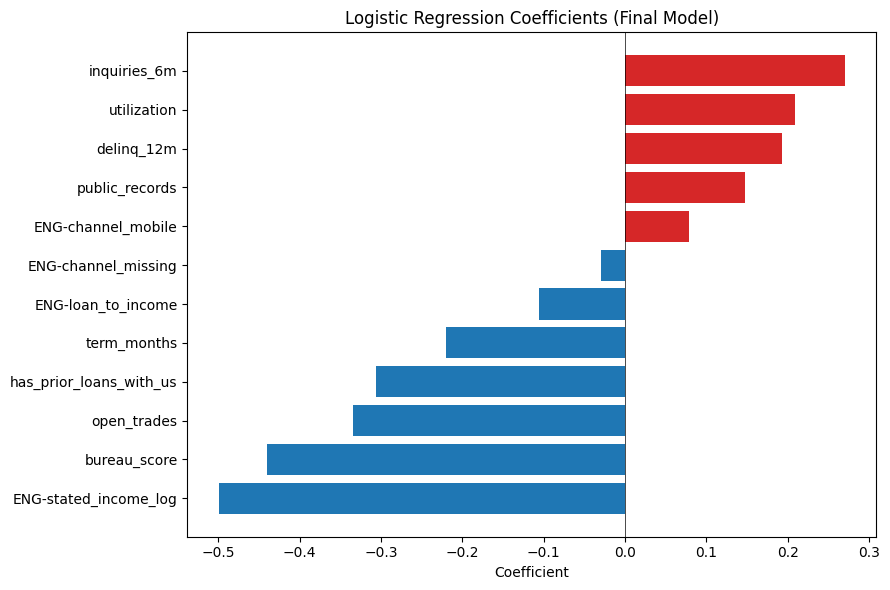

In [33]:
df_coef_plot = df_coef.sort_values('coef', ascending=True)
colors = ['tab:red' if c > 0 else 'tab:blue' for c in df_coef_plot['coef']]
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Logistic Regression Coefficients (Final Model)')
ax.barh(df_coef_plot['feature'], df_coef_plot['coef'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/coefficients_final.png', bbox_inches='tight', dpi=150)
plt.show()

## Save Inference Model

In [34]:
# save
str_filename = 'cls_model_inference.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
joblib.dump(cls_model_inference, str_local_path)

['./output/cls_model_inference.joblib']

## Isotonic Calibration

In [35]:
# Calibrate using isotonic regression on validation set
from sklearn.isotonic import IsotonicRegression

y_hat_valid_uncal = cls_model_inference.predict_proba(X_valid[list_feats_final])[:, 1]
y_hat_test_uncal = cls_model_inference.predict_proba(X_test[list_feats_final])[:, 1]

iso_reg = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
iso_reg.fit(y_hat_valid_uncal, y_valid)

y_hat_test_cal = iso_reg.predict(y_hat_test_uncal)

print(f'Uncalibrated ROC AUC (Test): {roc_auc_score(y_test, y_hat_test_uncal):0.4f}')
print(f'Calibrated ROC AUC (Test):   {roc_auc_score(y_test, y_hat_test_cal):0.4f}')
print(f'Uncalibrated PR AUC (Test):  {average_precision_score(y_test, y_hat_test_uncal):0.4f}')
print(f'Calibrated PR AUC (Test):    {average_precision_score(y_test, y_hat_test_cal):0.4f}')

# Save calibration model
joblib.dump(iso_reg, f'{str_dirname_output}/cls_calibration.joblib')

Uncalibrated ROC AUC (Test): 0.7578
Calibrated ROC AUC (Test):   0.7561
Uncalibrated PR AUC (Test):  0.3949
Calibrated PR AUC (Test):    0.3806


['./output/cls_calibration.joblib']

## ROC, Precision-Recall, and Calibration Curves

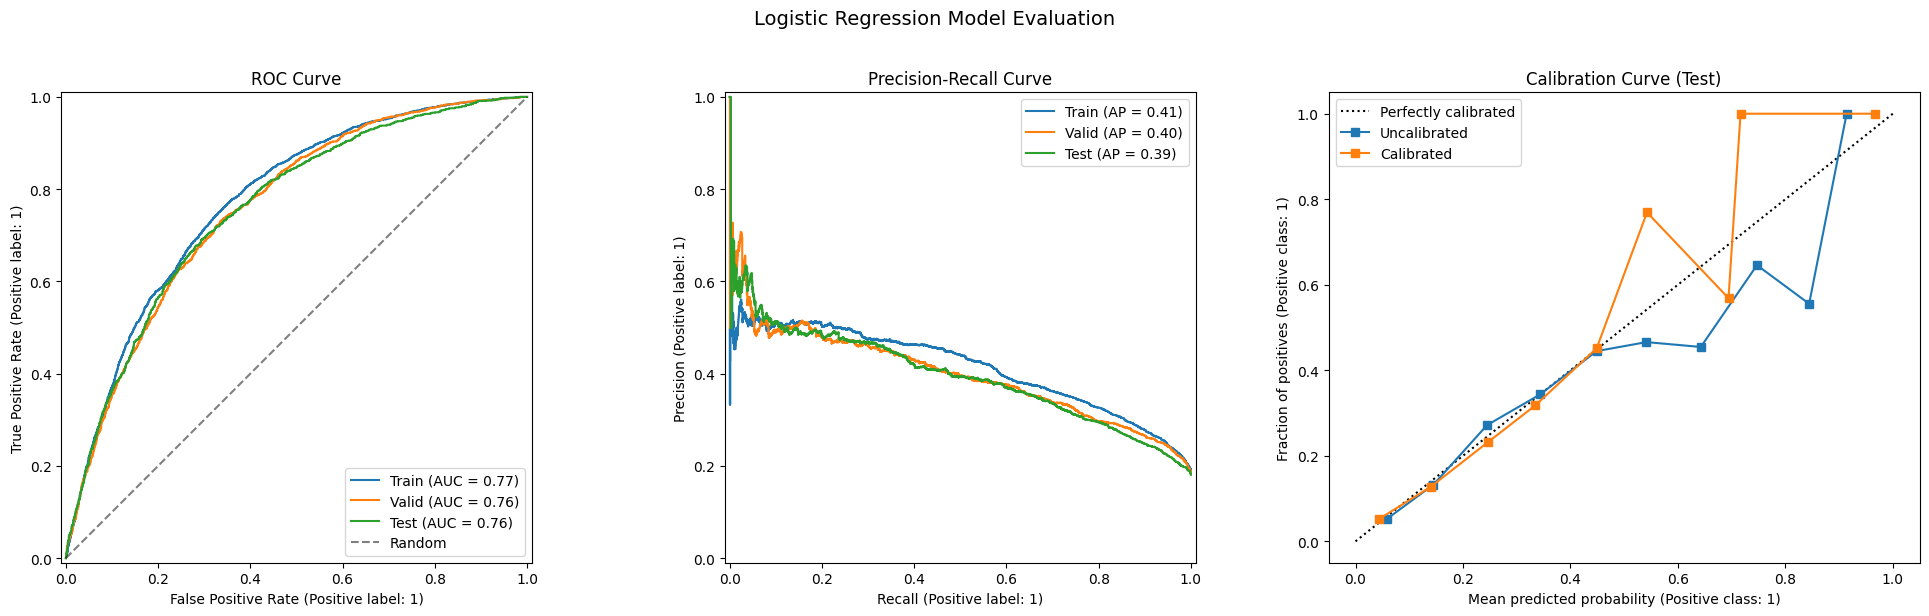

In [36]:
y_hat_train_final = cls_model_inference.predict_proba(X_train[list_feats_final])[:, 1]
y_hat_valid_final = cls_model_inference.predict_proba(X_valid[list_feats_final])[:, 1]
y_hat_test_final = cls_model_inference.predict_proba(X_test[list_feats_final])[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Logistic Regression Model Evaluation', fontsize=14, y=1.02)

# ROC Curve
RocCurveDisplay.from_predictions(y_train, y_hat_train_final, name='Train', ax=axes[0])
RocCurveDisplay.from_predictions(y_valid, y_hat_valid_final, name='Valid', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_hat_test_final, name='Test', ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_train, y_hat_train_final, name='Train', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_valid, y_hat_valid_final, name='Valid', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_hat_test_final, name='Test', ax=axes[1])
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')

# Calibration Curve
CalibrationDisplay.from_predictions(y_test, y_hat_test_final, n_bins=10, name='Uncalibrated', ax=axes[2])
CalibrationDisplay.from_predictions(y_test, y_hat_test_cal, n_bins=10, name='Calibrated', ax=axes[2])
axes[2].set_title('Calibration Curve (Test)')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/roc_pr_calibration.png', bbox_inches='tight', dpi=150)
plt.show()

## Prediction Distribution Analysis

In [37]:
# import data
df = pd.read_csv(str_uri)
# dtm
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
# get age
df['age'] = (pd.Timestamp.today() - df['dob']).dt.days // 365
# make binary
df['age_group'] = df['age'].apply(
    lambda x: 'young' if x < 60 else 'old'
)
df

,loan_id,origination_date,dob,loan_amount,term_months,channel,employment_length_years,stated_income,state,has_prior_loans_with_us,...,utilization,inquiries_6m,public_records,default_12m,charged_off_amount,paid_interest_amount,apr,data_set,age,age_group
0,17794,2022-01-01,1992-02-29,5410,18,partner,8.39,2951.0,WI,0,...,0.47,3.0,1,0,0.00,1715.89,0.221,train,34,young
1,13499,2022-01-01,1966-05-05,10000,12,web,4.52,5410.0,FL,0,...,0.46,3.0,0,0,0.00,1672.59,0.209,train,59,young
2,24476,2022-01-01,1985-02-06,8480,12,web,3.81,3244.0,TX,0,...,0.48,5.0,2,0,0.00,2379.19,0.303,train,41,young
3,5438,2022-01-01,1981-11-06,3510,18,web,9.82,5147.0,IL,1,...,0.18,1.0,0,0,0.00,706.84,0.150,train,44,young
4,11493,2022-01-01,1991-11-27,6630,24,web,4.99,6389.0,TX,1,...,0.41,3.0,1,0,0.00,2160.10,0.159,train,34,young
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,23591,2024-12-28,1975-12-12,6970,12,mobile,9.41,6511.0,WA,0,...,0.47,4.0,1,0,0.00,1147.42,0.200,test,50,young
25304,15828,2024-12-28,1984-11-26,8450,12,mobile,8.97,4278.0,TN,1,...,0.52,2.0,0,0,0.00,1163.61,0.160,test,41,young
25305,17304,2024-12-28,2003-07-07,970,24,web,4.01,3885.0,MO,0,...,0.34,0.0,0,0,0.00,287.05,0.166,test,22,young
25306,13374,2024-12-28,1975-12-01,5700,12,mobile,7.10,13121.0,GA,0,...,0.31,2.0,2,0,0.00,803.60,0.156,test,50,young


In [38]:
# import preprocessor
str_filename = 'cls_model_preprocessing.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
cls_model_preprocessing = joblib.load(str_local_path)

In [39]:
# preprocess df
df = cls_model_preprocessing.transform(X=df)

Generic cleaning...
Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 1285.31it/s]

Feature engineering...
Scaling features...


In [40]:
# import inference model
str_filename = 'cls_model_inference.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
cls_model_inference = joblib.load(str_local_path)
# get cols
list_feats_final = list(cls_model_inference.feature_names_in_)

In [41]:
# generate predictions
df['yhat'] = cls_model_inference.predict_proba(df[list_feats_final])[:, 1]

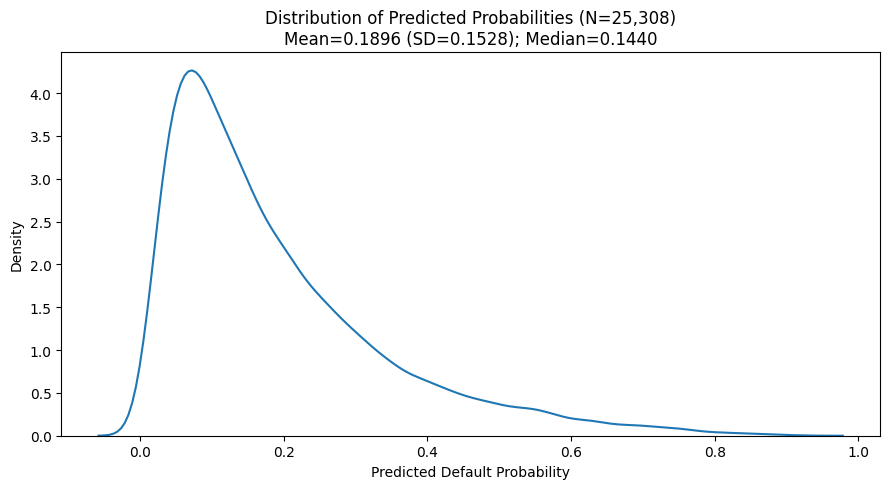

In [42]:
int_n = df.shape[0]
flt_mn = df['yhat'].mean()
flt_sd = df['yhat'].std()
flt_mdn = df['yhat'].median()

str_title = f'Distribution of Predicted Probabilities (N={int_n:,})\nMean={flt_mn:.4f} (SD={flt_sd:.4f}); Median={flt_mdn:.4f}'

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title(str_title)
sns.kdeplot(df['yhat'], ax=ax)
ax.set_xlabel('Predicted Default Probability')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/prediction_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## Disparate Impact Analysis (Age)

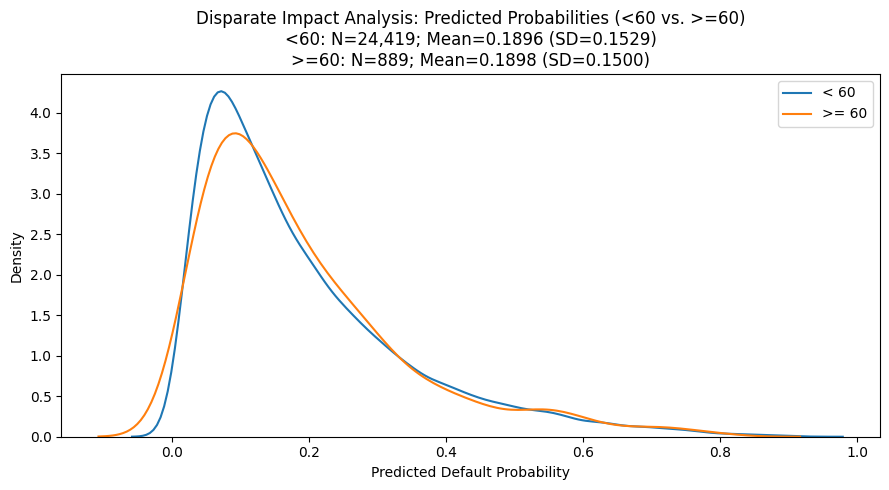

In [43]:
# plot - young
df_young = df[df['age_group'] == 'young'].copy()
int_n_young = df_young.shape[0]
flt_mn_young = df_young['yhat'].mean()
flt_sd_young = df_young['yhat'].std()
flt_mdn_young = df_young['yhat'].median()
# plot - old
df_old = df[df['age_group'] == 'old'].copy()
int_n_old = df_old.shape[0]
flt_mn_old = df_old['yhat'].mean()
flt_sd_old = df_old['yhat'].std()
flt_mdn_old = df_old['yhat'].median()

str_title = (f'Disparate Impact Analysis: Predicted Probabilities (<60 vs. >=60)\n'
             f'<60: N={int_n_young:,}; Mean={flt_mn_young:.4f} (SD={flt_sd_young:.4f})\n'
             f'>=60: N={int_n_old:,}; Mean={flt_mn_old:.4f} (SD={flt_sd_old:.4f})')

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title(str_title)
sns.kdeplot(df_young['yhat'], ax=ax, label='< 60')
sns.kdeplot(df_old['yhat'], ax=ax, label='>= 60')
ax.set_xlabel('Predicted Default Probability')
ax.legend()
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/disparate_impact.png', bbox_inches='tight', dpi=150)
plt.show()

## Save Test Predictions (for Model Comparison)

In [44]:
df_test_preds = pd.DataFrame({
    'y_test': y_test.values,
    'y_hat_test': y_hat_test_final,
    'y_hat_test_calibrated': y_hat_test_cal,
})
df_test_preds.to_csv(f'{str_dirname_output}/test_predictions.csv', index=False)
print(f'Saved {len(df_test_preds)} test predictions')

Saved 6327 test predictions
